In [17]:
## IMPORTS
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier, StackingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# visualization
import seaborn as sns

In [2]:
diabet = pd.read_csv('pima_indians_diabetes.csv')
diabet.head()

,time_pregnant_no,plasma_concentration,diastolic_blood_pressure,triceps_skinfold_thickness,serum_insulin,bmi,diabetes_pedigree,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
diabet.dtypes

time_pregnant_no                int64
plasma_concentration            int64
diastolic_blood_pressure        int64
triceps_skinfold_thickness      int64
serum_insulin                   int64
bmi                           float64
diabetes_pedigree             float64
age                             int64
class                           int64
dtype: object

In [4]:
total = diabet.isnull().sum().sort_values(ascending=False)
percent = (diabet.isnull().sum() / diabet.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=["Total", 'Percent'])
missing_data

,Total,Percent
time_pregnant_no,0,0.0
plasma_concentration,0,0.0
diastolic_blood_pressure,0,0.0
triceps_skinfold_thickness,0,0.0
serum_insulin,0,0.0
bmi,0,0.0
diabetes_pedigree,0,0.0
age,0,0.0
class,0,0.0


no missing values

<Axes: >

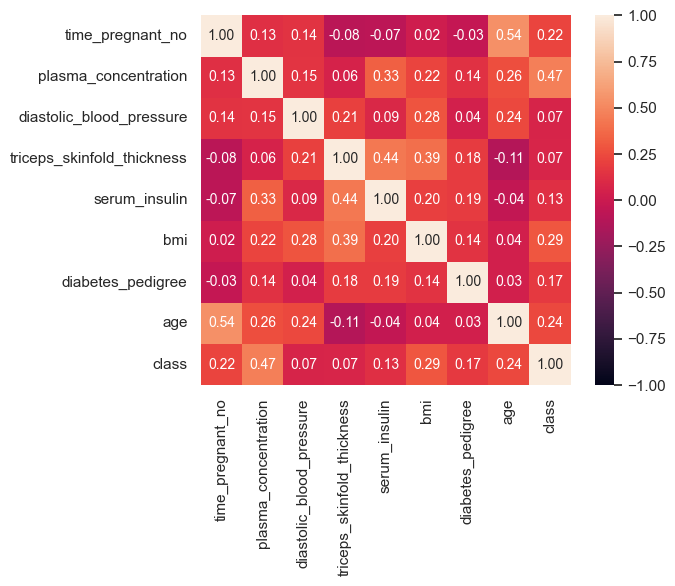

In [183]:
sns.heatmap(diabet.corr(), annot=True, annot_kws={'size': 10}, fmt='.2f', square=True, vmax=1, vmin=-1)

array([[<Axes: title={'center': 'time_pregnant_no'}>,
        <Axes: title={'center': 'plasma_concentration'}>,
        <Axes: title={'center': 'diastolic_blood_pressure'}>],
       [<Axes: title={'center': 'triceps_skinfold_thickness'}>,
        <Axes: title={'center': 'serum_insulin'}>,
        <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'diabetes_pedigree'}>,
        <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'class'}>]], dtype=object)

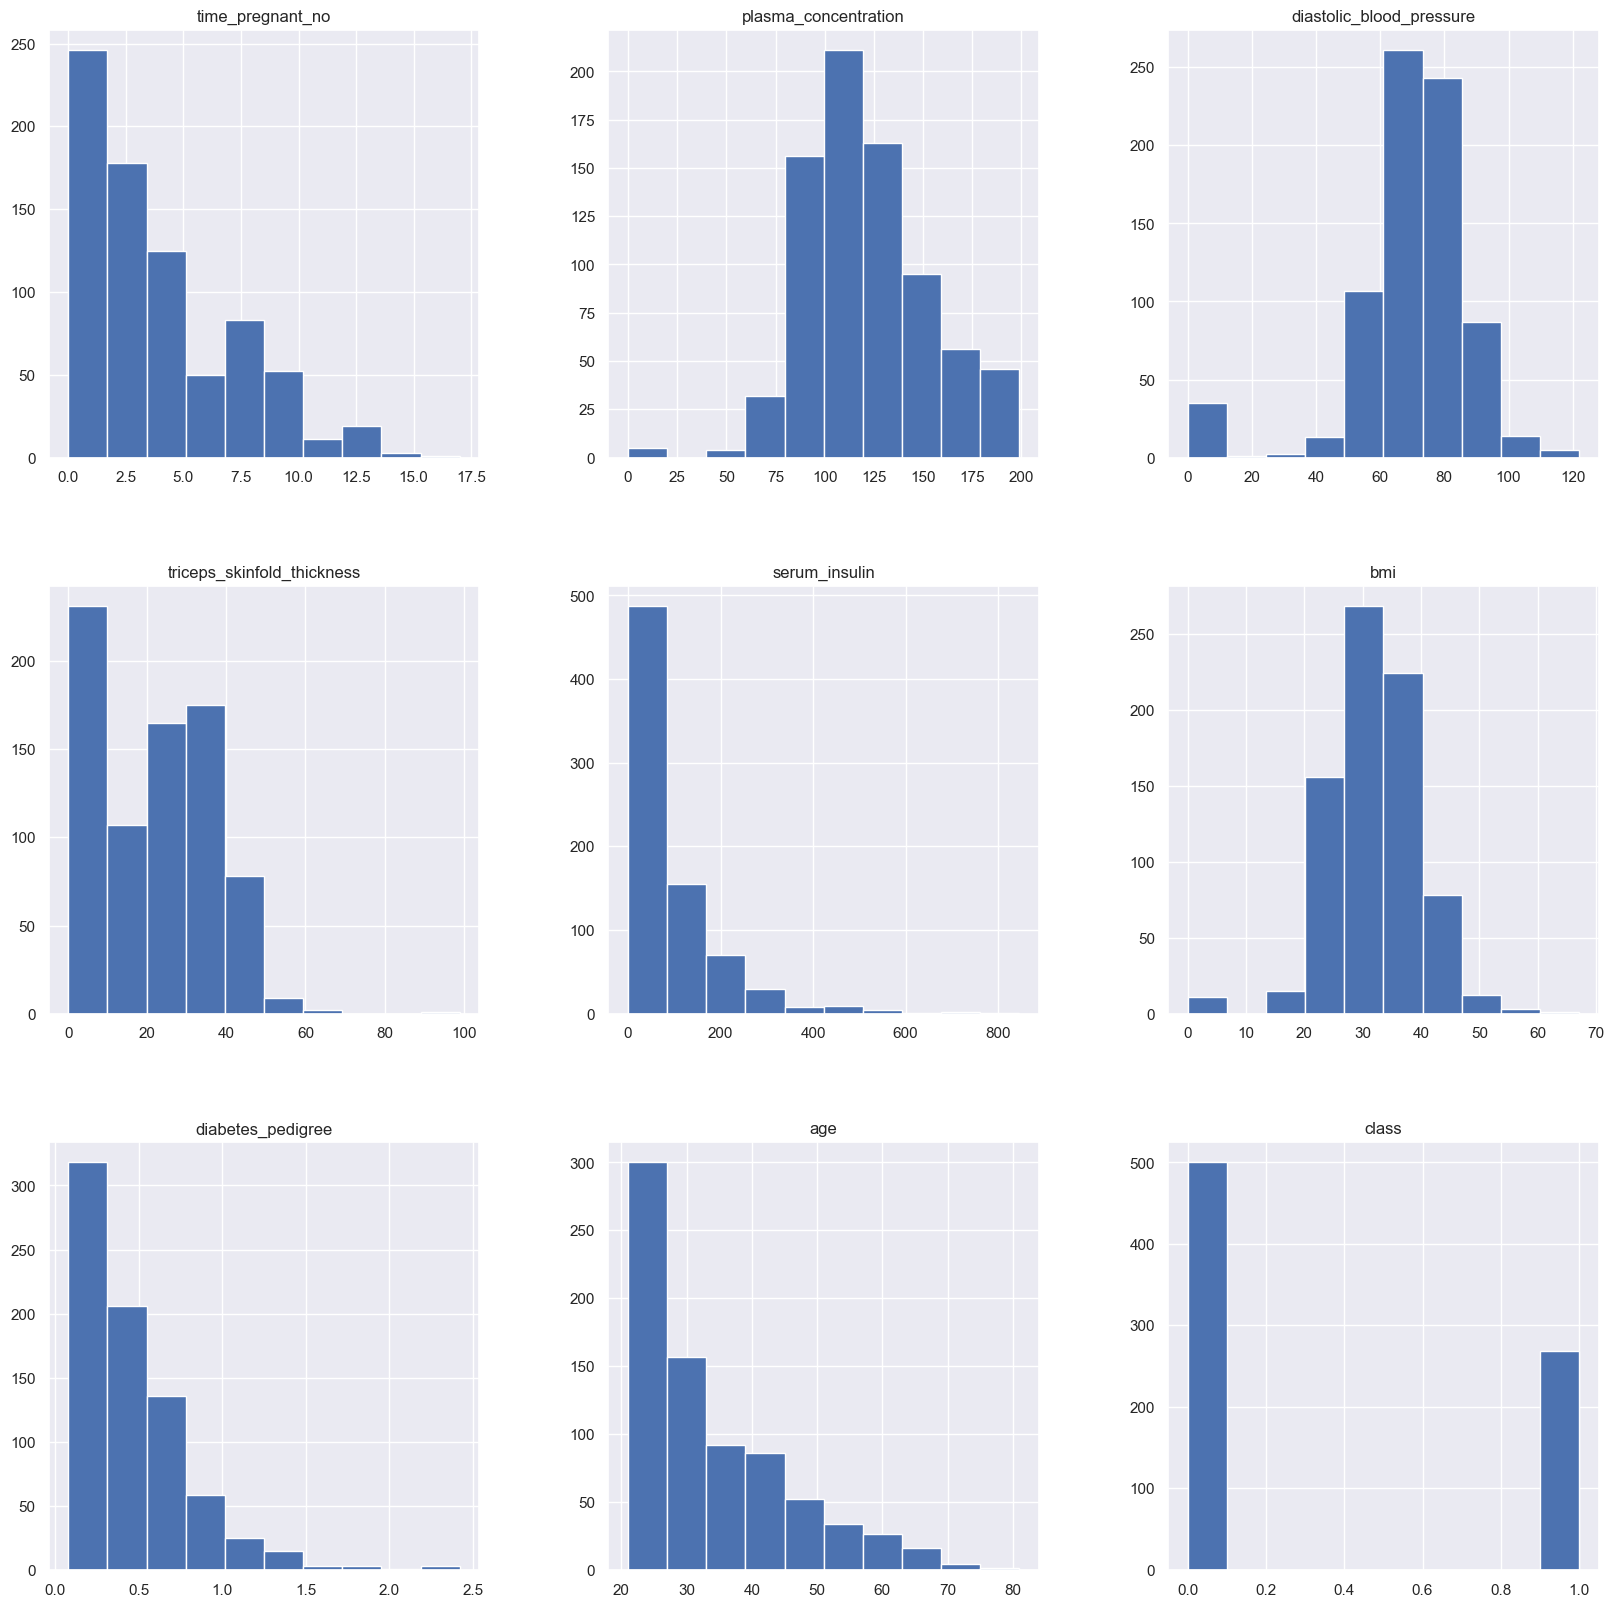

In [184]:
diabet.hist(figsize = (20,20))

In [9]:
diabet_label = diabet['class']
diabet_feature = diabet.drop(['class'], axis=1)

In [10]:
# Standard Scaling
mean = np.mean(diabet_feature, axis=0)
std = np.std(diabet_feature, axis=0)

diabet_feature = (diabet_feature - mean) / std

In [11]:
# split the data:
indices = list(range(diabet.shape[0]))

np.random.shuffle(indices)

split_index = int(diabet.shape[0] * 0.8)

train_indices = indices[:split_index]
test_indices = indices[split_index:]

x_train, x_test = diabet_feature.iloc[train_indices], diabet_feature.iloc[test_indices]
y_train, y_test = diabet_label.iloc[train_indices], diabet_label.iloc[test_indices]

## Task 'a'

In [188]:
n_estimators = [100, 200, 300]
max_features = [None, 'sqrt', 'log2']
max_depth = [10, 20, None]

In [189]:
best_accuracy = 0
best_params = {}

for n in n_estimators:
    for f in max_features:
        for d in max_depth:
            rf = RandomForestClassifier(n_estimators=n, max_features=f, max_depth=d, random_state=42)
            rf.fit(x_train, y_train)

            y_train_pred = rf.predict(x_train)
            y_test_pred = rf.predict(x_test)

            train_accuracy = accuracy_score(y_train, y_train_pred)
            test_accuracy = accuracy_score(y_test, y_test_pred)

            print(f'n_estimators: {n}, max_features: {f}, max_depth: {d}')
            print(f'Training Accuracy: {train_accuracy:.2f}, Test Accuracy: {test_accuracy:.2f}\n')

            if test_accuracy > best_accuracy:
                best_accuracy = test_accuracy
                best_params = {'n_estimators': n, 'max_features': f, 'max_depth': d}

print(f'**********Best Parameters: {best_params}**********')
print(f'**********Best Test Accuracy: {best_accuracy:.2f}**********')

n_estimators: 100, max_features: None, max_depth: 10
Training Accuracy: 1.00, Test Accuracy: 0.80

n_estimators: 100, max_features: None, max_depth: 20
Training Accuracy: 1.00, Test Accuracy: 0.78

n_estimators: 100, max_features: None, max_depth: None
Training Accuracy: 1.00, Test Accuracy: 0.78

n_estimators: 100, max_features: sqrt, max_depth: 10
Training Accuracy: 1.00, Test Accuracy: 0.79

n_estimators: 100, max_features: sqrt, max_depth: 20
Training Accuracy: 1.00, Test Accuracy: 0.78

n_estimators: 100, max_features: sqrt, max_depth: None
Training Accuracy: 1.00, Test Accuracy: 0.79

n_estimators: 100, max_features: log2, max_depth: 10
Training Accuracy: 1.00, Test Accuracy: 0.78

n_estimators: 100, max_features: log2, max_depth: 20
Training Accuracy: 1.00, Test Accuracy: 0.79

n_estimators: 100, max_features: log2, max_depth: None
Training Accuracy: 1.00, Test Accuracy: 0.79

n_estimators: 200, max_features: None, max_depth: 10
Training Accuracy: 1.00, Test Accuracy: 0.79

n_es

so now we know that:

Best Parameters: {'n_estimators': 100, 'max_features': 'sqrt', 'max_depth': 20}

Best Test Accuracy: 0.79

## Task'b'

## Task 'c'

In [12]:
# Define parameter grids for each model
param_grids = {
    'Bagging': {
        'n_estimators': [10, 20, 50, 100],
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.5],
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7],
    }}

In [13]:
Bagging = BaggingClassifier(estimator=RandomForestClassifier(random_state=42), random_state=42)
AdaBoost = AdaBoostClassifier(random_state=42)
GBoost = GradientBoostingClassifier(random_state=42)

In [14]:
results = {}
models = {
    'Bagging': Bagging,
    'AdaBoost': AdaBoost,
    'Gradient Boosting': GBoost
}

In [15]:
#Grid Search for each model
for model_name, model in models.items():
    print(f"Tuning hyperparameters for {model_name}...")
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[model_name],
        scoring='accuracy',
        cv=5,  # 5-fold
        verbose=1,
        n_jobs=-1
    )
    grid_search.fit(x_train, y_train)
    results[model_name] = grid_search.best_score_

# print optimal parameters
print("\nOptimal Parameters:")
for model_name, params in results.items():
    print(f"{model_name}: {results[model_name]}\n")

Tuning hyperparameters for Bagging...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Tuning hyperparameters for AdaBoost...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Tuning hyperparameters for Gradient Boosting...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Optimal Parameters:
Bagging: 0.7785019325603093

AdaBoost: 0.7719578835132614

Gradient Boosting: 0.775223244035719



In [ ]:
# Define 3 base models
base_models = [
    ('log_reg', LogisticRegression(max_iter=1000, random_state=42)),
    ('decision_tree', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svm', SVC(kernel='linear', probability=True, random_state=42))
]

# Define the stacking ensemble with a meta-learner
stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(random_state=42)
)

# Train the ensemble model
stacking_model.fit(x_train, y_train)

# predictions and accuracy
y_pred = stacking_model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Stacking Ensemble Accuracy: {accuracy}")

Stacking Ensemble Accuracy: 0.7662337662337663
